# EDA 12 - Revenue by Product or Customer Segment

This notebook analyzes revenue, growth, share, volatility, and margin behavior by segment using `orders.csv`, `order_items.csv`, and `products.csv`, with optional context from `customers.csv` and `sales.csv` when available.

## 1. Setup and file discovery

Locate required and optional files recursively from the current working directory. Tables and charts are displayed directly in the notebook; no EDA outputs are saved to files.

In [1]:
import os
import re
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 280)
pd.set_option("display.max_rows", 300)
pd.set_option("display.max_colwidth", 180)

PROJECT_ROOT = Path(os.getcwd())
REQUIRED_FILES = ["orders.csv", "order_items.csv", "products.csv"]
OPTIONAL_FILES = ["customers.csv", "sales.csv"]
ALL_FILES = REQUIRED_FILES + OPTIONAL_FILES
TOP_N_SEGMENTS = 8

warning_messages = []
loaded_files = {}
file_paths = {}
analysis_ready = False
margin_available = False
premium_segment_available = False

segment_items = pd.DataFrame()
segment_revenue = pd.DataFrame()
margin_by_segment = pd.DataFrame()
monthly_segment = pd.DataFrame()
monthly_pivot = pd.DataFrame()
growth_df = pd.DataFrame()
fastest_growing_df = pd.DataFrame()
fastest_declining_df = pd.DataFrame()
steady_growth_df = pd.DataFrame()
unstable_segment_df = pd.DataFrame()
monthly_share_plot_df = pd.DataFrame()
feature_preview = pd.DataFrame()
revenue_validation_df = pd.DataFrame()

top_segment_names = []
weakest_segment_names = []
premium_margin_statement = "Not evaluated."
mix_change_statement = "Not evaluated."
forecast_feature_warning = "Future segment mix must not be used directly for forecasting unless it is separately forecasted."
recommended_segment_features = [
    "segment_revenue_lag",
    "segment_share_lag",
    "segment_growth_rate_lag",
    "top_segment_revenue_lag",
    "top_segment_share_lag",
    "segment_mix_concentration_lag",
    "premium_segment_share_lag",
]


def money_formatter(value, _position=None):
    if pd.isna(value):
        return ""
    abs_value = abs(value)
    if abs_value >= 1_000_000_000:
        return f"{value / 1_000_000_000:,.1f}B"
    if abs_value >= 1_000_000:
        return f"{value / 1_000_000:,.1f}M"
    if abs_value >= 1_000:
        return f"{value / 1_000:,.0f}K"
    return f"{value:,.0f}"


currency_axis = FuncFormatter(money_formatter)

for filename in ALL_FILES:
    matches = sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))
    file_paths[filename] = matches[0] if matches else None

file_discovery_df = pd.DataFrame([
    {
        "file": filename,
        "required": filename in REQUIRED_FILES,
        "found": file_paths[filename] is not None,
        "path": str(file_paths[filename].relative_to(PROJECT_ROOT)) if file_paths[filename] else None,
        "match_count": len(sorted(PROJECT_ROOT.rglob(filename), key=lambda p: (len(p.parts), str(p).lower()))),
    }
    for filename in ALL_FILES
])

missing_required = [filename for filename in REQUIRED_FILES if file_paths[filename] is None]
if missing_required:
    warning_messages.append("Required files not found: " + ", ".join(missing_required))

missing_optional = [filename for filename in OPTIONAL_FILES if file_paths[filename] is None]
if missing_optional:
    warning_messages.append("Optional files not found: " + ", ".join(missing_optional))

print(f"Project root: {PROJECT_ROOT}")
display(file_discovery_df)

Project root: D:\Code\Datathon 2026


,file,required,found,path,match_count
0,orders.csv,True,True,datathon-2026-round-1\orders.csv,1
1,order_items.csv,True,True,datathon-2026-round-1\order_items.csv,1
2,products.csv,True,True,datathon-2026-round-1\products.csv,1
3,customers.csv,False,True,datathon-2026-round-1\customers.csv,1
4,sales.csv,False,True,datathon-2026-round-1\sales.csv,1


## 2. Load required and optional files

Load all available CSV files safely. Missing optional files are reported and skipped.

In [2]:
load_rows = []
for filename in ALL_FILES:
    path = file_paths.get(filename)
    if path is None:
        loaded_files[filename] = None
        load_rows.append({"file": filename, "required": filename in REQUIRED_FILES, "loaded": False, "rows": np.nan, "columns": np.nan, "error": "file not found"})
        continue
    try:
        df = pd.read_csv(path, low_memory=False)
        loaded_files[filename] = df
        load_rows.append({"file": filename, "required": filename in REQUIRED_FILES, "loaded": True, "rows": len(df), "columns": len(df.columns), "error": ""})
    except Exception as exc:
        loaded_files[filename] = None
        warning_messages.append(f"Could not load {filename}: {repr(exc)}")
        load_rows.append({"file": filename, "required": filename in REQUIRED_FILES, "loaded": False, "rows": np.nan, "columns": np.nan, "error": repr(exc)})

load_summary_df = pd.DataFrame(load_rows)
display(load_summary_df)

for filename in ALL_FILES:
    df = loaded_files.get(filename)
    if df is not None:
        print(f"Preview: {filename}")
        display(df.head())

,file,required,loaded,rows,columns,error
0,orders.csv,True,True,646945,8,
1,order_items.csv,True,True,714669,7,
2,products.csv,True,True,2412,8,
3,customers.csv,False,True,121930,7,
4,sales.csv,False,True,3833,3,


Preview: orders.csv


,order_id,order_date,customer_id,zip,order_status,payment_method,device_type,order_source
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign


Preview: order_items.csv


,order_id,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2
0,1,2400,7,1138.22,0.0,NaN,NaN
1,2,609,7,10166.25,0.0,NaN,NaN
2,3,396,3,11220.33,0.0,NaN,NaN
3,4,635,5,10639.25,0.0,NaN,NaN
4,6,1935,1,1597.84,0.0,NaN,NaN


...

,product_id,product_name,category,segment,size,color,price,cogs
0,536,SaigonFlex UC-01,Streetwear,Everyday,S,green,11059.650000,9704.842875
1,537,SaigonFlex UC-02,Streetwear,Everyday,M,silver,9523.076013,5393.870254
2,538,SaigonFlex UC-03,Streetwear,Everyday,L,pink,15951.633158,11371.919278
3,539,SaigonFlex UC-04,Streetwear,Everyday,XL,yellow,15753.717299,8573.172954
4,540,SaigonFlex UC-05,Streetwear,Everyday,S,red,15766.334536,14063.570406


Preview: customers.csv


,customer_id,zip,city,signup_date,gender,age_group,acquisition_channel
0,1,15201,Hai Phong,2021-12-30,Female,35-44,social_media
1,2,15201,Hai Phong,2013-12-27,Female,45-54,email_campaign
2,3,15201,Hai Phong,2018-07-24,Female,18-24,organic_search
3,4,15201,Hai Phong,2017-11-29,Male,35-44,referral
4,5,15201,Hai Phong,2022-09-23,Male,55+,organic_search


Preview: sales.csv


,Date,Revenue,COGS
0,2012-07-04,5123547.94,3982991.19
1,2012-07-05,2751773.45,2150580.23
2,2012-07-06,3054029.42,2517632.84
3,2012-07-07,2667930.94,2108246.62
4,2012-07-08,2360851.90,1808622.79


## 3. Identify key, date, segment, revenue, and margin columns

Infer join keys, segment fields, revenue fields, and margin-related fields. Segment candidates are searched across products, customers, and orders; the chosen segment source is displayed clearly. For this dataset, `unit_price` is already the post-promotion unit price, so item revenue is reconstructed as `quantity * unit_price`. `discount_amount` is kept as a discount field and must not be treated as revenue.

In [3]:
def normalize_name(name):
    return re.sub(r"[^a-z0-9]+", "_", str(name).strip().lower()).strip("_")


def non_empty_mask(series):
    if pd.api.types.is_object_dtype(series) or pd.api.types.is_string_dtype(series):
        return series.astype("string").str.strip().ne("") & series.notna()
    return series.notna()


def numeric_series(series):
    if pd.api.types.is_numeric_dtype(series):
        return pd.to_numeric(series, errors="coerce")
    cleaned = (
        series.astype("string")
        .str.strip()
        .str.replace(",", "", regex=False)
        .str.replace("$", "", regex=False)
        .str.replace(r"^\((.*)\)$", r"-\1", regex=True)
    )
    return pd.to_numeric(cleaned, errors="coerce")


def parse_datetime_series(series):
    if pd.api.types.is_datetime64_any_dtype(series):
        return pd.to_datetime(series, errors="coerce")
    return pd.to_datetime(series, errors="coerce")


def date_score(column_name, series):
    name = normalize_name(column_name)
    name_tokens = set(name.split("_"))
    name_points = 0
    if name in {"date", "order_date", "created_at", "timestamp", "transaction_date", "sales_date"}:
        name_points += 5
    elif "date" in name_tokens or "date" in name or "timestamp" in name or "time" in name:
        name_points += 3
    if pd.api.types.is_numeric_dtype(series) and name_points == 0:
        return {"column": column_name, "date_score": -5.0, "date_parse_success": 0.0, "plausible_date_share": 0.0}
    parsed = parse_datetime_series(series)
    mask = non_empty_mask(series)
    non_empty = int(mask.sum())
    parse_success = float(parsed[mask].notna().mean()) if non_empty else 0.0
    parsed_valid = parsed[mask].dropna()
    if len(parsed_valid):
        plausible_share = float(parsed_valid.between(pd.Timestamp("1990-01-01"), pd.Timestamp("2100-12-31")).mean())
        unique_dates = int(parsed_valid.dt.normalize().nunique())
    else:
        plausible_share = 0.0
        unique_dates = 0
    score = name_points + 3 * parse_success + 2 * plausible_share + min(unique_dates / 20, 1)
    return {"column": column_name, "date_score": round(score, 4), "date_parse_success": round(parse_success, 4), "plausible_date_share": round(plausible_share, 4)}


def string_key_values(series):
    return series.dropna().astype("string").str.strip()


def key_candidates(df, key_kind):
    if df is None or df.empty:
        return []
    candidates = []
    for col in df.columns:
        name = normalize_name(col)
        name_tokens = set(name.split("_"))
        score = 0
        if key_kind == "order":
            if name in {"order_id", "orderid", "id_order"}:
                score += 8
            if "order" in name_tokens or "order" in name:
                score += 4
        if key_kind == "product":
            if name in {"product_id", "productid", "sku", "item_id"}:
                score += 8
            if "product" in name_tokens or "product" in name or "sku" in name:
                score += 4
        if key_kind == "customer":
            if name in {"customer_id", "customerid", "user_id", "client_id"}:
                score += 8
            if "customer" in name_tokens or "customer" in name or "client" in name or "user" in name:
                score += 4
        if "id" in name_tokens or name.endswith("_id") or name == "id":
            score += 3
        if "date" in name or "time" in name:
            score -= 5
        if score > 0:
            candidates.append((col, score))
    if not candidates:
        for col in df.columns:
            if df[col].nunique(dropna=True) > 1:
                candidates.append((col, 0))
    return candidates


def choose_join_key(left_df, right_df, key_kind):
    rows = []
    for left_col, left_name_score in key_candidates(left_df, key_kind):
        left_values = set(string_key_values(left_df[left_col]).unique())
        for right_col, right_name_score in key_candidates(right_df, key_kind):
            right_values = set(string_key_values(right_df[right_col]).unique())
            overlap_rate = len(left_values & right_values) / max(1, len(left_values)) if left_values and right_values else 0.0
            score = left_name_score + right_name_score + 10 * overlap_rate
            rows.append({
                "left_column": left_col,
                "right_column": right_col,
                "key_kind": key_kind,
                "score": score,
                "left_name_score": left_name_score,
                "right_name_score": right_name_score,
                "left_unique": len(left_values),
                "right_unique": len(right_values),
                "left_unique_overlap_rate": overlap_rate,
            })
    result = pd.DataFrame(rows).sort_values(["score", "left_unique_overlap_rate"], ascending=False) if rows else pd.DataFrame()
    if result.empty:
        return None, None, result
    best = result.iloc[0]
    if best["left_unique_overlap_rate"] < 0.05 and best["score"] < 8:
        return None, None, result
    return best["left_column"], best["right_column"], result


def choose_date_column(df):
    if df is None or df.empty:
        return None, pd.DataFrame()
    candidates = pd.DataFrame([date_score(col, df[col]) for col in df.columns])
    candidates = candidates.sort_values(["date_score", "date_parse_success", "plausible_date_share"], ascending=False)
    if candidates.empty:
        return None, candidates
    best = candidates.iloc[0]
    if best["date_parse_success"] >= 0.50 and best["plausible_date_share"] >= 0.50:
        return best["column"], candidates
    return None, candidates


def segment_candidates_for_table(table_name, df):
    if df is None or df.empty:
        return []
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = df[col]
        non_null = values.notna().sum()
        unique = values.nunique(dropna=True)
        unique_rate = unique / max(non_null, 1)
        score = 0
        if name == "segment":
            score += 12
        if "segment" in name:
            score += 10
        if any(term in name for term in ["tier", "class", "group", "cohort", "persona", "market"]):
            score += 4
        if name in {"age_group", "customer_type", "lifecycle_stage", "acquisition_channel"}:
            score += 3
        if table_name == "products.csv" and ("segment" in name or name in {"segment", "category", "department"}):
            score += 3
        if table_name == "customers.csv" and any(term in name for term in ["segment", "tier", "group", "cohort", "age_group"]):
            score += 3
        if pd.api.types.is_object_dtype(values) or pd.api.types.is_string_dtype(values):
            score += 2
        if 2 <= unique <= 100:
            score += 2
        if unique_rate > 0.75:
            score -= 4
        if any(term in name for term in ["id", "date", "price", "cost", "revenue", "amount", "zip", "color", "size"]):
            score -= 4
        if score > 0:
            rows.append({"source_table": table_name, "column": col, "segment_score": score, "unique_values": unique, "unique_rate": unique_rate})
    return rows


def choose_numeric_by_terms(df, positive_terms, negative_terms=None):
    negative_terms = negative_terms or []
    if df is None or df.empty:
        return None, pd.DataFrame()
    rows = []
    for col in df.columns:
        name = normalize_name(col)
        values = numeric_series(df[col])
        non_empty = max(int(non_empty_mask(df[col]).sum()), 1)
        numeric_success = values.notna().sum() / non_empty
        if numeric_success < 0.70:
            continue
        score = numeric_success
        positive_term_match = any(term in name for term in positive_terms)
        for term in positive_terms:
            if term in name:
                score += 5
        for term in negative_terms:
            if term in name:
                score -= 5
        if values.dropna().std(ddof=1) > 0:
            score += 1
        rows.append({
            "column": col,
            "score": score,
            "positive_term_match": positive_term_match,
            "numeric_parse_success": numeric_success,
            "mean": values.mean(),
            "std": values.std(ddof=1),
        })
    candidates = pd.DataFrame(rows).sort_values("score", ascending=False) if rows else pd.DataFrame()
    if candidates.empty or candidates.iloc[0]["score"] <= 1 or not bool(candidates.iloc[0]["positive_term_match"]):
        return None, candidates
    return candidates.iloc[0]["column"], candidates


orders = loaded_files.get("orders.csv")
order_items = loaded_files.get("order_items.csv")
products = loaded_files.get("products.csv")
customers = loaded_files.get("customers.csv")

if orders is None or order_items is None or products is None:
    detection_summary_df = pd.DataFrame([{"warning": "One or more required files were not loaded."}])
    order_id_items_col = order_id_orders_col = product_id_items_col = product_id_products_col = None
    customer_id_orders_col = customer_id_customers_col = None
    order_date_col = segment_source_table = segment_col = None
    quantity_col = price_col = discount_col = direct_revenue_col = item_cost_col = product_cost_col = profit_col = margin_col = None
    revenue_method = "not available"
else:
    order_id_items_col, order_id_orders_col, order_key_candidates_df = choose_join_key(order_items, orders, "order")
    product_id_items_col, product_id_products_col, product_key_candidates_df = choose_join_key(order_items, products, "product")
    customer_id_orders_col = customer_id_customers_col = None
    customer_key_candidates_df = pd.DataFrame()
    if customers is not None:
        customer_id_orders_col, customer_id_customers_col, customer_key_candidates_df = choose_join_key(orders, customers, "customer")

    order_date_col, order_date_candidates_df = choose_date_column(orders)
    segment_candidates_df = pd.DataFrame(
        segment_candidates_for_table("products.csv", products)
        + segment_candidates_for_table("customers.csv", customers)
        + segment_candidates_for_table("orders.csv", orders)
    ).sort_values(["segment_score", "unique_values"], ascending=[False, True])
    if not segment_candidates_df.empty:
        best_segment = segment_candidates_df.iloc[0]
        segment_source_table = best_segment["source_table"]
        segment_col = best_segment["column"]
    else:
        segment_source_table = None
        segment_col = None

    quantity_col, quantity_candidates_df = choose_numeric_by_terms(order_items, ["quantity", "qty", "units"], ["price", "discount", "amount"])
    price_col, price_candidates_df = choose_numeric_by_terms(order_items, ["unit_price", "price", "sales_price", "item_price"], ["discount", "quantity", "qty", "id"])
    discount_col, discount_candidates_df = choose_numeric_by_terms(order_items, ["discount"], ["id", "date"])
    direct_revenue_col, direct_revenue_candidates_df = choose_numeric_by_terms(
        order_items,
        ["revenue", "line_total", "item_total", "sales_amount", "net_sales", "subtotal", "line_subtotal", "total"],
        ["discount", "price", "cost", "cogs", "quantity", "qty", "id"],
    )
    item_cost_col, item_cost_candidates_df = choose_numeric_by_terms(order_items, ["cogs", "cost"], ["price", "discount", "quantity", "id"])
    product_cost_col, product_cost_candidates_df = choose_numeric_by_terms(products, ["cogs", "cost"], ["price", "id"])
    profit_col, profit_candidates_df = choose_numeric_by_terms(order_items, ["profit"], ["id", "margin"])
    margin_col, margin_candidates_df = choose_numeric_by_terms(order_items, ["margin"], ["id"])

    if quantity_col is not None and price_col is not None:
        revenue_method = f"inferred: {quantity_col} * {price_col} (unit price is post-discount)"
    elif direct_revenue_col is not None:
        revenue_method = f"direct column: {direct_revenue_col}"
    else:
        revenue_method = "not available"

    detection_summary_df = pd.DataFrame([{
        "order_id_in_order_items": order_id_items_col,
        "order_id_in_orders": order_id_orders_col,
        "product_id_in_order_items": product_id_items_col,
        "product_id_in_products": product_id_products_col,
        "customer_id_in_orders": customer_id_orders_col,
        "customer_id_in_customers": customer_id_customers_col,
        "order_date_column": order_date_col,
        "chosen_segment_source_table": segment_source_table,
        "chosen_segment_column": segment_col,
        "direct_revenue_column": direct_revenue_col,
        "quantity_column": quantity_col,
        "price_column": price_col,
        "discount_column": discount_col,
        "item_cost_column": item_cost_col,
        "product_cost_column": product_cost_col,
        "profit_column": profit_col,
        "margin_column": margin_col,
        "revenue_method": revenue_method,
    }])

display(detection_summary_df)

for label, df in [
    ("Order key candidates", locals().get("order_key_candidates_df", pd.DataFrame())),
    ("Product key candidates", locals().get("product_key_candidates_df", pd.DataFrame())),
    ("Customer key candidates", locals().get("customer_key_candidates_df", pd.DataFrame())),
    ("Order date candidates", locals().get("order_date_candidates_df", pd.DataFrame())),
    ("Segment candidates", locals().get("segment_candidates_df", pd.DataFrame())),
    ("Direct revenue candidates", locals().get("direct_revenue_candidates_df", pd.DataFrame())),
    ("Quantity candidates", locals().get("quantity_candidates_df", pd.DataFrame())),
    ("Price candidates", locals().get("price_candidates_df", pd.DataFrame())),
    ("Discount candidates", locals().get("discount_candidates_df", pd.DataFrame())),
    ("Item cost candidates", locals().get("item_cost_candidates_df", pd.DataFrame())),
    ("Product cost candidates", locals().get("product_cost_candidates_df", pd.DataFrame())),
    ("Profit candidates", locals().get("profit_candidates_df", pd.DataFrame())),
    ("Margin candidates", locals().get("margin_candidates_df", pd.DataFrame())),
]:
    if isinstance(df, pd.DataFrame) and not df.empty:
        print(label)
        display(df.head(12))

,order_id_in_order_items,order_id_in_orders,product_id_in_order_items,product_id_in_products,customer_id_in_orders,customer_id_in_customers,order_date_column,chosen_segment_source_table,chosen_segment_column,direct_revenue_column,quantity_column,price_column,discount_column,item_cost_column,product_cost_column,profit_column,margin_column,revenue_method
0,order_id,order_id,product_id,product_id,customer_id,customer_id,order_date,products.csv,segment,None,quantity,unit_price,discount_amount,None,cogs,None,None,inferred: quantity * unit_price (unit price is post-discount)


Order key candidates


,left_column,right_column,key_kind,score,left_name_score,right_name_score,left_unique,right_unique,left_unique_overlap_rate
0,order_id,order_id,order,40.000000,15,15,646945,646945,1.000000
4,product_id,order_id,order,25.484355,3,15,1598,646945,0.748436
1,order_id,customer_id,order,19.076908,15,3,646945,90246,0.107691
2,order_id,order_status,order,19.000000,15,4,646945,6,0.000000
3,order_id,order_source,order,19.000000,15,4,646945,6,0.000000
8,promo_id,order_id,order,18.000000,3,15,50,646945,0.000000
12,promo_id_2,order_id,order,18.000000,3,15,2,646945,0.000000
5,product_id,customer_id,order,11.782228,3,3,1598,90246,0.578223
6,product_id,order_status,order,7.000000,3,4,1598,6,0.000000
7,product_id,order_source,order,7.000000,3,4,1598,6,0.000000


Product key candidates


,left_column,right_column,key_kind,score,left_name_score,right_name_score,left_unique,right_unique,left_unique_overlap_rate
2,product_id,product_id,product,40.000000,15,15,1598,2412,1.000000
3,product_id,product_name,product,19.000000,15,4,1598,2172,0.000000
0,order_id,product_id,product,18.028163,3,15,646945,2412,0.002816
4,promo_id,product_id,product,18.000000,3,15,50,2412,0.000000
6,promo_id_2,product_id,product,18.000000,3,15,2,2412,0.000000
1,order_id,product_name,product,7.000000,3,4,646945,2172,0.000000
5,promo_id,product_name,product,7.000000,3,4,50,2172,0.000000
7,promo_id_2,product_name,product,7.000000,3,4,2,2172,0.000000


...

,column,score,positive_term_match,numeric_parse_success,mean,std
2,cogs,7.0,True,1.0,3868.346732,3878.584151
0,product_id,-3.0,False,1.0,1206.500000,696.428747
1,price,-3.0,False,1.0,4928.216231,4776.737669


Profit candidates


,column,score,positive_term_match,numeric_parse_success,mean,std
2,quantity,2.0,False,1.0,4.495988,2.290143
4,discount_amount,2.0,False,1.0,1048.887415,2280.530606
3,unit_price,2.0,False,1.0,5114.690157,3774.817912
0,order_id,-3.0,False,1.0,411615.076561,240480.310686
1,product_id,-3.0,False,1.0,1234.931370,691.332564


Margin candidates


,column,score,positive_term_match,numeric_parse_success,mean,std
2,quantity,2.0,False,1.0,4.495988,2.290143
4,discount_amount,2.0,False,1.0,1048.887415,2280.530606
3,unit_price,2.0,False,1.0,5114.690157,3774.817912
0,order_id,-3.0,False,1.0,411615.076561,240480.310686
1,product_id,-3.0,False,1.0,1234.931370,691.332564


## 4. Build joined segment-level dataset

Join order items to orders and products, optionally customers when the chosen segment comes from customers or customer-level fields are available. Item revenue is inferred from quantity and price when needed, and margin is estimated when cost or profit data is available.

In [4]:
def compute_item_revenue(df):
    if quantity_col is not None and price_col is not None:
        quantity = numeric_series(df[quantity_col]).fillna(0)
        price = numeric_series(df[price_col]).fillna(0)
        return quantity * price
    if direct_revenue_col is not None and direct_revenue_col in df.columns:
        return numeric_series(df[direct_revenue_col])
    return pd.Series(np.nan, index=df.index)


required_detection = [order_id_items_col, order_id_orders_col, product_id_items_col, product_id_products_col, order_date_col, segment_source_table, segment_col]
if orders is None or order_items is None or products is None or any(value is None for value in required_detection) or revenue_method == "not available":
    analysis_ready = False
    missing_pieces = []
    if orders is None: missing_pieces.append("orders.csv")
    if order_items is None: missing_pieces.append("order_items.csv")
    if products is None: missing_pieces.append("products.csv")
    if order_id_items_col is None or order_id_orders_col is None: missing_pieces.append("order key")
    if product_id_items_col is None or product_id_products_col is None: missing_pieces.append("product key")
    if order_date_col is None: missing_pieces.append("order date")
    if segment_source_table is None or segment_col is None: missing_pieces.append("segment")
    if revenue_method == "not available": missing_pieces.append("item revenue fields")
    warning_messages.append("Segment analysis could not be fully prepared because these pieces are missing: " + ", ".join(missing_pieces))
    display(pd.DataFrame([{"ready": False, "missing_pieces": ", ".join(missing_pieces)}]))
else:
    orders_dim_cols = [order_id_orders_col, order_date_col]
    if customer_id_orders_col is not None and customer_id_orders_col in orders.columns:
        orders_dim_cols.append(customer_id_orders_col)
    if segment_source_table == "orders.csv" and segment_col not in orders_dim_cols:
        orders_dim_cols.append(segment_col)
    orders_dim = orders[orders_dim_cols].copy()

    product_dim_cols = [product_id_products_col]
    if segment_source_table == "products.csv":
        product_dim_cols.append(segment_col)
    if product_cost_col is not None and product_cost_col not in product_dim_cols:
        product_dim_cols.append(product_cost_col)
    products_dim = products[product_dim_cols].copy()

    customer_dim = None
    use_customers = customers is not None and customer_id_orders_col is not None and customer_id_customers_col is not None
    if use_customers:
        customer_dim_cols = [customer_id_customers_col]
        if segment_source_table == "customers.csv" and segment_col not in customer_dim_cols:
            customer_dim_cols.append(segment_col)
        customer_dim = customers[customer_dim_cols].copy()

    order_duplicate_keys = int(orders_dim.duplicated(order_id_orders_col, keep=False).sum())
    product_duplicate_keys = int(products_dim.duplicated(product_id_products_col, keep=False).sum())
    customer_duplicate_keys = int(customer_dim.duplicated(customer_id_customers_col, keep=False).sum()) if customer_dim is not None else 0
    if order_duplicate_keys:
        warning_messages.append(f"orders.csv has {order_duplicate_keys:,} rows on duplicated order keys; first row per key was used for joining.")
    if product_duplicate_keys:
        warning_messages.append(f"products.csv has {product_duplicate_keys:,} rows on duplicated product keys; first row per key was used for joining.")
    if customer_duplicate_keys:
        warning_messages.append(f"customers.csv has {customer_duplicate_keys:,} rows on duplicated customer keys; first row per key was used for joining.")

    orders_dim = orders_dim.drop_duplicates(order_id_orders_col, keep="first")
    products_dim = products_dim.drop_duplicates(product_id_products_col, keep="first")
    if customer_dim is not None:
        customer_dim = customer_dim.drop_duplicates(customer_id_customers_col, keep="first")

    items = order_items.copy()
    items["item_revenue"] = compute_item_revenue(items)
    if item_cost_col is not None and item_cost_col in items.columns:
        items["item_cost_from_items"] = numeric_series(items[item_cost_col])

    joined = items.merge(
        orders_dim,
        left_on=order_id_items_col,
        right_on=order_id_orders_col,
        how="left",
        indicator="order_join_status",
        suffixes=("", "_orders"),
    )
    joined = joined.merge(
        products_dim,
        left_on=product_id_items_col,
        right_on=product_id_products_col,
        how="left",
        indicator="product_join_status",
        suffixes=("", "_products"),
    )
    if use_customers:
        joined = joined.merge(
            customer_dim,
            left_on=customer_id_orders_col,
            right_on=customer_id_customers_col,
            how="left",
            indicator="customer_join_status",
            suffixes=("", "_customers"),
        )
    else:
        joined["customer_join_status"] = "not_used"

    if segment_source_table == "products.csv":
        segment_values = joined[segment_col]
    elif segment_source_table == "customers.csv":
        segment_values = joined[segment_col]
    else:
        segment_values = joined[segment_col]

    quantity_values = numeric_series(joined[quantity_col]) if quantity_col is not None and quantity_col in joined.columns else pd.Series(np.nan, index=joined.index)
    product_cost_values = numeric_series(joined[product_cost_col]) if product_cost_col is not None and product_cost_col in joined.columns else pd.Series(np.nan, index=joined.index)

    if profit_col is not None and profit_col in joined.columns:
        gross_profit = numeric_series(joined[profit_col])
        cogs = numeric_series(joined["item_revenue"]) - gross_profit
        margin_source = f"profit column: {profit_col}"
    elif "item_cost_from_items" in joined.columns:
        cogs = joined["item_cost_from_items"]
        gross_profit = numeric_series(joined["item_revenue"]) - cogs
        margin_source = f"item cost column: {item_cost_col}"
    elif product_cost_col is not None and product_cost_col in joined.columns and quantity_col is not None:
        cogs = product_cost_values * quantity_values.fillna(0)
        gross_profit = numeric_series(joined["item_revenue"]) - cogs
        margin_source = f"product unit cost column: {product_cost_col} * {quantity_col}"
    else:
        cogs = pd.Series(np.nan, index=joined.index)
        gross_profit = pd.Series(np.nan, index=joined.index)
        margin_source = "not available"

    segment_items = pd.DataFrame({
        "order_date": parse_datetime_series(joined[order_date_col]).dt.normalize(),
        "order_id": joined[order_id_items_col],
        "product_id": joined[product_id_items_col],
        "segment": segment_values.astype("string").replace("", pd.NA).fillna("Unknown"),
        "revenue": numeric_series(joined["item_revenue"]),
        "cogs": cogs,
        "gross_profit": gross_profit,
        "order_join_status": joined["order_join_status"].astype(str),
        "product_join_status": joined["product_join_status"].astype(str),
        "customer_join_status": joined["customer_join_status"].astype(str),
    })
    if customer_id_orders_col is not None and customer_id_orders_col in joined.columns:
        segment_items["customer_id"] = joined[customer_id_orders_col]
    if quantity_col is not None and quantity_col in joined.columns:
        segment_items["quantity"] = quantity_values
    if price_col is not None and price_col in joined.columns:
        segment_items["price"] = numeric_series(joined[price_col])
    if discount_col is not None and discount_col in joined.columns:
        segment_items["discount"] = numeric_series(joined[discount_col])

    before_filter_rows = len(segment_items)
    invalid_date_rows = int(segment_items["order_date"].isna().sum())
    invalid_revenue_rows = int(segment_items["revenue"].isna().sum())
    segment_items = segment_items.dropna(subset=["order_date", "revenue"]).copy()
    segment_items["month"] = segment_items["order_date"].dt.to_period("M").dt.to_timestamp()
    segment_items["gross_margin_pct"] = np.where(segment_items["revenue"].abs() < 1e-9, np.nan, segment_items["gross_profit"] / segment_items["revenue"])
    margin_available = segment_items["gross_profit"].notna().any()

    analysis_ready = not segment_items.empty
    if not analysis_ready:
        warning_messages.append("No valid joined segment rows remained after dropping missing order dates or revenue.")
    if not margin_available:
        warning_messages.append("Margin cannot be evaluated because no cost, COGS, profit, or margin-like fields were identified.")

    total_item_revenue = float(segment_items["revenue"].sum()) if analysis_ready else np.nan
    total_discount_amount = float(segment_items["discount"].sum()) if analysis_ready and "discount" in segment_items else np.nan
    sales = loaded_files.get("sales.csv")
    sales_revenue_total = np.nan
    sales_revenue_difference = np.nan
    sales_revenue_difference_pct = np.nan
    if sales is not None and not sales.empty:
        sales_revenue_col, sales_revenue_candidates_df = choose_numeric_by_terms(
            sales,
            ["revenue", "sales"],
            ["cost", "cogs", "discount", "id", "date"],
        )
        if sales_revenue_col is not None:
            sales_revenue_total = float(numeric_series(sales[sales_revenue_col]).sum())
            sales_revenue_difference = total_item_revenue - sales_revenue_total
            sales_revenue_difference_pct = sales_revenue_difference / sales_revenue_total if sales_revenue_total else np.nan

    build_summary_df = pd.DataFrame([{
        "ready": analysis_ready,
        "segment_source_table": segment_source_table,
        "segment_column": segment_col,
        "revenue_method": revenue_method,
        "margin_source": margin_source,
        "margin_available": margin_available,
        "order_items_rows": len(order_items),
        "joined_rows_before_filter": before_filter_rows,
        "analysis_rows_after_filter": len(segment_items),
        "invalid_order_date_rows": invalid_date_rows,
        "invalid_revenue_rows": invalid_revenue_rows,
        "negative_revenue_rows": int((segment_items["revenue"] < 0).sum()),
        "zero_revenue_rows": int((segment_items["revenue"] == 0).sum()),
        "first_order_date": segment_items["order_date"].min().date() if analysis_ready else None,
        "last_order_date": segment_items["order_date"].max().date() if analysis_ready else None,
        "segment_count": segment_items["segment"].nunique() if analysis_ready else 0,
    }])
    revenue_validation_df = pd.DataFrame([{
        "item_revenue_formula": revenue_method,
        "item_revenue_total": total_item_revenue,
        "sales_csv_revenue_total": sales_revenue_total,
        "difference_vs_sales_csv": sales_revenue_difference,
        "difference_pct_vs_sales_csv": sales_revenue_difference_pct,
        "discount_amount_total_not_revenue": total_discount_amount,
    }])
    if pd.notna(sales_revenue_difference) and abs(sales_revenue_difference) > max(1e-6, abs(sales_revenue_total) * 1e-9):
        warning_messages.append("Reconstructed item revenue does not reconcile to sales.csv Revenue; inspect unit price and discount semantics before using segment conclusions.")
    display(build_summary_df)
    display(revenue_validation_df)
    display(segment_items.head(10))

,ready,segment_source_table,segment_column,revenue_method,margin_source,margin_available,order_items_rows,joined_rows_before_filter,analysis_rows_after_filter,invalid_order_date_rows,invalid_revenue_rows,negative_revenue_rows,zero_revenue_rows,first_order_date,last_order_date,segment_count
0,True,products.csv,segment,inferred: quantity * unit_price (unit price is post-discount),product unit cost column: cogs * quantity,True,714669,714669,714669,0,0,0,0,2012-07-04,2022-12-31,8


,item_revenue_formula,item_revenue_total,sales_csv_revenue_total,difference_vs_sales_csv,difference_pct_vs_sales_csv,discount_amount_total_not_revenue
0,inferred: quantity * unit_price (unit price is post-discount),1.643048e+10,1.643048e+10,0.000004,2.321720e-16,749607320.1


,order_date,order_id,product_id,segment,revenue,cogs,gross_profit,order_join_status,product_join_status,customer_join_status,customer_id,quantity,price,discount,month,gross_margin_pct
0,2012-07-04,1,2400,Trendy,7967.54,7376.586059,590.953941,both,both,both,58578,7,1138.22,0.0,2012-07-01,0.074170
1,2012-07-04,2,609,Everyday,71163.75,62913.929616,8249.820384,both,both,both,58621,7,10166.25,0.0,2012-07-01,0.115927
2,2012-07-04,3,396,Balanced,33660.99,30273.036767,3387.953233,both,both,both,58811,3,11220.33,0.0,2012-07-01,0.100649
3,2012-07-04,4,635,Everyday,53196.25,46027.152390,7169.097610,both,both,both,59453,5,10639.25,0.0,2012-07-01,0.134767
4,2012-07-06,6,1935,Activewear,1597.84,1048.696357,549.143643,both,both,both,57821,1,1597.84,0.0,2012-07-01,0.343679
5,2012-07-06,7,1934,Activewear,9800.94,8027.018786,1773.921214,both,both,both,57820,6,1633.49,0.0,2012-07-01,0.180995
6,2012-07-06,8,1934,Activewear,9617.52,8027.018786,1590.501214,both,both,both,57818,6,1602.92,0.0,2012-07-01,0.165375
7,2012-07-06,8,1935,Activewear,6570.04,4194.785429,2375.254571,both,both,both,57818,4,1642.51,0.0,2012-07-01,0.361528
8,2012-07-06,9,1432,Activewear,32397.12,31112.424000,1284.696000,both,both,both,49102,8,4049.64,0.0,2012-07-01,0.039655
9,2012-07-06,10,1431,Activewear,19886.85,13366.061100,6520.788900,both,both,both,49101,5,3977.37,0.0,2012-07-01,0.327895


## 5. Join quality checks

Report join match rates for orders and products, and customers when the customer table is used.

In [5]:
if not analysis_ready:
    print("WARNING: Skipping join quality checks because the joined dataset is not available.")
else:
    order_match_count = int((segment_items["order_join_status"] == "both").sum())
    product_match_count = int((segment_items["product_join_status"] == "both").sum())
    customer_used = bool((segment_items["customer_join_status"] != "not_used").any())
    customer_match_count = int((segment_items["customer_join_status"] == "both").sum()) if customer_used else np.nan
    join_quality_df = pd.DataFrame([{
        "analysis_rows": len(segment_items),
        "rows_matched_to_orders": order_match_count,
        "rows_unmatched_to_orders": len(segment_items) - order_match_count,
        "order_match_rate": order_match_count / len(segment_items),
        "rows_matched_to_products": product_match_count,
        "rows_unmatched_to_products": len(segment_items) - product_match_count,
        "product_match_rate": product_match_count / len(segment_items),
        "customers_join_used": customer_used,
        "rows_matched_to_customers": customer_match_count,
        "rows_unmatched_to_customers": (len(segment_items) - customer_match_count) if customer_used else np.nan,
        "customer_match_rate": (customer_match_count / len(segment_items)) if customer_used else np.nan,
    }])
    display(join_quality_df)

    unmatched_orders = segment_items.loc[segment_items["order_join_status"] != "both", "order_id"].drop_duplicates().head(20)
    unmatched_products = segment_items.loc[segment_items["product_join_status"] != "both", "product_id"].drop_duplicates().head(20)
    if len(unmatched_orders):
        print("Sample unmatched order IDs")
        display(unmatched_orders.to_frame())
    if len(unmatched_products):
        print("Sample unmatched product IDs")
        display(unmatched_products.to_frame())
    if customer_used and "customer_id" in segment_items.columns:
        unmatched_customers = segment_items.loc[segment_items["customer_join_status"] != "both", "customer_id"].drop_duplicates().head(20)
        if len(unmatched_customers):
            print("Sample unmatched customer IDs")
            display(unmatched_customers.to_frame())
    if not len(unmatched_orders) and not len(unmatched_products):
        print("No unmatched order or product keys in the filtered analysis dataset.")

,analysis_rows,rows_matched_to_orders,rows_unmatched_to_orders,order_match_rate,rows_matched_to_products,rows_unmatched_to_products,product_match_rate,customers_join_used,rows_matched_to_customers,rows_unmatched_to_customers,customer_match_rate
0,714669,714669,0,1.0,714669,0,1.0,True,714669,0,1.0


No unmatched order or product keys in the filtered analysis dataset.


## 6. Revenue by segment

Aggregate revenue by segment, calculate share and order/item/product/customer counts, and identify the best-selling and weakest segments.

,segment,total_revenue,number_of_orders,number_of_order_items,number_of_unique_products,average_revenue_per_order_item,number_of_unique_customers,revenue_share,average_revenue_per_order,rank_by_total_revenue
0,Everyday,5.376849e+09,181514,182533,319,29456.858005,60757,0.327248,29622.225626,1
1,Balanced,5.127409e+09,103023,103333,201,49620.242551,46273,0.312067,49769.551687,2
2,Performance,2.390412e+09,96303,96730,244,24712.209461,40622,0.145486,24821.781473,3
3,Activewear,2.047815e+09,171011,230375,430,8889.051434,55320,0.124635,11974.757321,4
4,Premium,4.801314e+08,30944,31032,89,15472.138064,20049,0.029222,15516.138456,5
5,All-weather,4.275845e+08,22553,22570,91,18944.817234,16674,0.026024,18959.097458,6
6,Trendy,3.435991e+08,37054,37159,111,9246.726106,23350,0.020912,9272.928573,7
7,Standard,2.366771e+08,10924,10937,113,21640.042580,9141,0.014405,21665.795103,8


Best-selling segments by revenue: Everyday, Balanced, Performance, Activewear, Premium
Weakest segments by revenue: Activewear, Premium, All-weather, Trendy, Standard


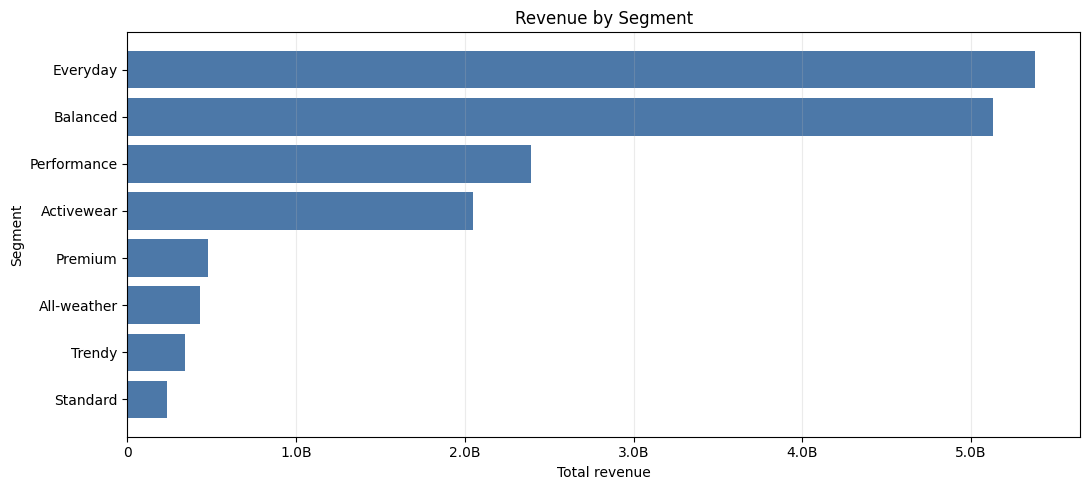

In [6]:
if not analysis_ready:
    print("WARNING: Skipping revenue by segment because the joined dataset is not available.")
else:
    total_revenue = segment_items["revenue"].sum()
    agg_kwargs = dict(
        total_revenue=("revenue", "sum"),
        number_of_orders=("order_id", "nunique"),
        number_of_order_items=("revenue", "size"),
        number_of_unique_products=("product_id", "nunique"),
        average_revenue_per_order_item=("revenue", "mean"),
    )
    if "customer_id" in segment_items.columns:
        agg_kwargs["number_of_unique_customers"] = ("customer_id", "nunique")
    segment_revenue = (
        segment_items.groupby("segment", dropna=False)
        .agg(**agg_kwargs)
        .sort_values("total_revenue", ascending=False)
        .reset_index()
    )
    segment_revenue["revenue_share"] = segment_revenue["total_revenue"] / total_revenue if total_revenue else np.nan
    segment_revenue["average_revenue_per_order"] = segment_revenue["total_revenue"] / segment_revenue["number_of_orders"].replace(0, np.nan)
    segment_revenue["rank_by_total_revenue"] = np.arange(1, len(segment_revenue) + 1)

    top_segment_names = segment_revenue.head(5)["segment"].astype(str).tolist()
    weakest_segment_names = segment_revenue.tail(5)["segment"].astype(str).tolist()

    display(segment_revenue)
    print("Best-selling segments by revenue:", ", ".join(top_segment_names))
    print("Weakest segments by revenue:", ", ".join(weakest_segment_names))

    plot_df = segment_revenue.head(20).sort_values("total_revenue", ascending=True)
    fig, ax = plt.subplots(figsize=(11, max(5, 0.38 * len(plot_df))))
    ax.barh(plot_df["segment"].astype(str), plot_df["total_revenue"], color="#4C78A8")
    ax.set_title("Revenue by Segment")
    ax.set_xlabel("Total revenue")
    ax.set_ylabel("Segment")
    ax.xaxis.set_major_formatter(currency_axis)
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 7. Margin by segment, if available

If cost, COGS, profit, or margin fields are available, estimate gross margin by segment. Premium/high-end comparison is attempted only when explicit premium-like segment labels are present.

,segment,total_revenue,total_cogs,gross_profit,average_margin_per_order_item,number_of_order_items,gross_margin_percentage,is_premium_or_high_end_label
7,Trendy,3.435991e+08,2.778738e+08,6.572530e+07,1768.758503,37159,0.191285,False
0,Activewear,2.047815e+09,1.684365e+09,3.634498e+08,1577.644270,230375,0.177482,False
6,Standard,2.366771e+08,1.969720e+08,3.970512e+07,3630.348004,10937,0.167761,False
3,Everyday,5.376849e+09,4.615280e+09,7.615685e+08,4172.223680,182533,0.141638,False
2,Balanced,5.127409e+09,4.469082e+09,6.583266e+08,6370.923309,103333,0.128394,False
4,Performance,2.390412e+09,2.111335e+09,2.790765e+08,2885.108298,96730,0.116748,False
5,Premium,4.801314e+08,4.276257e+08,5.250571e+07,1691.986143,31032,0.109357,True
1,All-weather,4.275845e+08,3.809160e+08,4.666849e+07,2067.722264,22570,0.109144,False


Premium/high-end labeled segments appear weaker on average margin: 10.94% vs 14.75% for other segments.


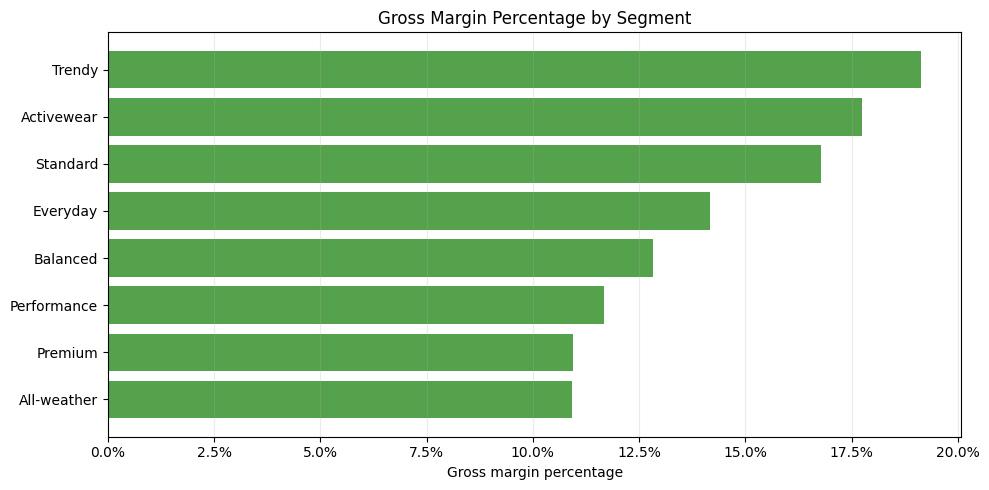

In [7]:
def is_premium_label(label):
    label_norm = normalize_name(label)
    premium_terms = ["premium", "luxury", "high_end", "highend", "elite", "pro", "prestige", "upper"]
    return any(term in label_norm for term in premium_terms)


if not analysis_ready:
    print("WARNING: Skipping margin analysis because the joined dataset is not available.")
elif not margin_available:
    premium_margin_statement = "Margin cannot be assessed from the current joined tables because no usable cost, COGS, profit, or margin-like fields were found."
    print(premium_margin_statement)
else:
    margin_by_segment = (
        segment_items.groupby("segment", dropna=False)
        .agg(
            total_revenue=("revenue", "sum"),
            total_cogs=("cogs", "sum"),
            gross_profit=("gross_profit", "sum"),
            average_margin_per_order_item=("gross_profit", "mean"),
            number_of_order_items=("revenue", "size"),
        )
        .reset_index()
    )
    margin_by_segment["gross_margin_percentage"] = np.where(
        margin_by_segment["total_revenue"].abs() < 1e-9,
        np.nan,
        margin_by_segment["gross_profit"] / margin_by_segment["total_revenue"],
    )
    margin_by_segment = margin_by_segment.sort_values("gross_margin_percentage", ascending=False)
    margin_by_segment["is_premium_or_high_end_label"] = margin_by_segment["segment"].astype(str).map(is_premium_label)
    premium_segment_available = bool(margin_by_segment["is_premium_or_high_end_label"].any())

    if premium_segment_available:
        premium_margin = margin_by_segment.loc[margin_by_segment["is_premium_or_high_end_label"], "gross_margin_percentage"].mean()
        other_margin = margin_by_segment.loc[~margin_by_segment["is_premium_or_high_end_label"], "gross_margin_percentage"].mean()
        if pd.notna(premium_margin) and pd.notna(other_margin):
            direction = "stronger" if premium_margin > other_margin else "weaker" if premium_margin < other_margin else "similar"
            premium_margin_statement = f"Premium/high-end labeled segments appear {direction} on average margin: {premium_margin:.2%} vs {other_margin:.2%} for other segments."
        else:
            premium_margin_statement = "Premium/high-end labels were found, but margin comparison is not available."
    else:
        top_margin_segment = margin_by_segment.iloc[0]["segment"] if len(margin_by_segment) else None
        top_margin = margin_by_segment.iloc[0]["gross_margin_percentage"] if len(margin_by_segment) else np.nan
        premium_margin_statement = f"No explicit premium/high-end segment label was detected. Highest gross margin segment is {top_margin_segment} at {top_margin:.2%}."

    display(margin_by_segment)
    print(premium_margin_statement)

    plot_df = margin_by_segment.sort_values("gross_margin_percentage", ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(5, 0.35 * len(plot_df))))
    ax.barh(plot_df["segment"].astype(str), plot_df["gross_margin_percentage"], color="#54A24B")
    ax.set_title("Gross Margin Percentage by Segment")
    ax.set_xlabel("Gross margin percentage")
    ax.xaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(axis="x", alpha=0.25)
    plt.tight_layout()
    plt.show()

## 8. Monthly revenue by segment

Aggregate segment revenue by month and plot segment revenue trends. If there are many segments, charts are limited to the top revenue segments.

Monthly segment revenue table


,month,segment,monthly_revenue,monthly_orders,monthly_items
0,2012-07-01,Activewear,16156559.40,1463,1995
1,2012-07-01,All-weather,2383588.69,135,136
2,2012-07-01,Balanced,31459467.26,598,599
3,2012-07-01,Everyday,55544495.80,1876,1884
4,2012-07-01,Performance,18625137.84,717,719
5,2012-07-01,Premium,1567131.71,122,122
6,2012-07-01,Standard,2419227.52,117,117
7,2012-07-01,Trendy,2251165.29,314,315
8,2012-08-01,Activewear,22464003.78,1961,2602
9,2012-08-01,All-weather,2606049.57,129,129


Monthly segment revenue pivot preview


segment,Everyday,Balanced,Performance,Activewear,Premium,All-weather,Trendy,Standard
month,,,,,,,,
2012-07-01,55544495.80,31459467.26,18625137.84,16156559.40,1567131.71,2383588.69,2251165.29,2419227.52
2012-08-01,62411073.16,40938548.47,21283859.27,22464003.78,3735335.70,2606049.57,2529211.73,3121158.63
2012-09-01,46290268.39,37610420.55,13646557.38,20900706.59,5259177.13,1833063.92,1671792.07,2095147.79
2012-10-01,42260977.82,30489735.92,10469285.29,17687122.57,4526225.23,1813957.84,1204681.44,1733708.34
2012-11-01,34538207.72,28102561.37,6864434.35,20256781.96,5052524.06,1497087.90,708131.37,1166566.51
2012-12-01,31244904.29,26644464.50,7958123.27,38648043.90,5918507.75,1594790.42,1145561.38,1168215.18
2013-01-01,30943836.18,26433956.79,7411492.50,18596026.26,4262136.55,1754302.63,693151.02,1213775.10
2013-02-01,38223244.72,30799991.36,12551118.11,18630037.95,4781430.68,2350419.14,732111.16,1714784.82
2013-03-01,59257311.58,35468473.16,21872297.01,23308065.54,5248450.72,2789209.83,1642340.47,2248508.96


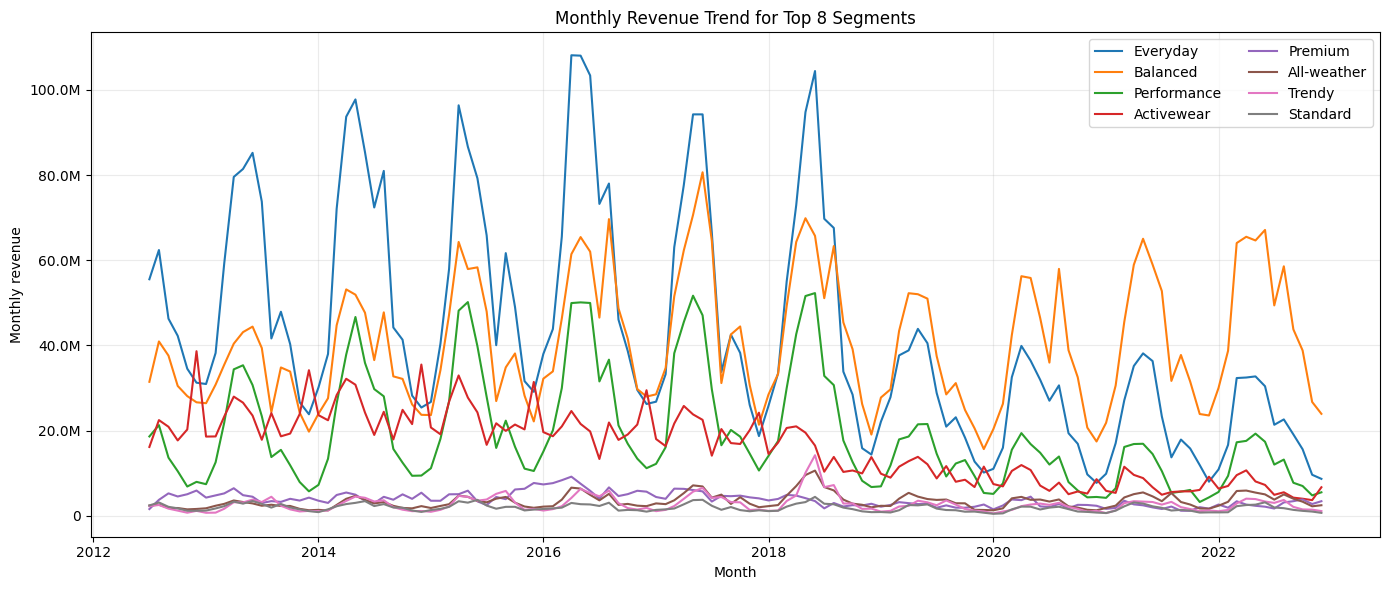

In [8]:
if not analysis_ready:
    print("WARNING: Skipping monthly segment trends because the joined dataset is not available.")
else:
    monthly_segment = (
        segment_items.groupby(["month", "segment"], as_index=False)
        .agg(monthly_revenue=("revenue", "sum"), monthly_orders=("order_id", "nunique"), monthly_items=("revenue", "size"))
        .sort_values(["month", "segment"])
    )
    full_months = pd.date_range(segment_items["month"].min(), segment_items["month"].max(), freq="MS")
    monthly_pivot = (
        monthly_segment.pivot(index="month", columns="segment", values="monthly_revenue")
        .reindex(full_months)
        .fillna(0)
    )
    monthly_pivot.index.name = "month"
    top_segments = segment_revenue.head(TOP_N_SEGMENTS)["segment"].tolist()

    print("Monthly segment revenue table")
    display(monthly_segment.head(30))
    print("Monthly segment revenue pivot preview")
    display(monthly_pivot[top_segments].head(12))

    fig, ax = plt.subplots(figsize=(14, 6))
    for segment in top_segments:
        ax.plot(monthly_pivot.index, monthly_pivot[segment], label=str(segment), linewidth=1.5)
    ax.set_title(f"Monthly Revenue Trend for Top {len(top_segments)} Segments")
    ax.set_xlabel("Month")
    ax.set_ylabel("Monthly revenue")
    ax.yaxis.set_major_formatter(currency_axis)
    ax.grid(alpha=0.25)
    ax.legend(ncol=2)
    plt.tight_layout()
    plt.show()

## 9. Segment growth and stability analysis

Calculate growth, recent-vs-earlier averages, compound monthly growth, and volatility. Minimum revenue and observation thresholds are applied before labeling segments as meaningfully growing or declining.

Segment growth indicators


,segment,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,steady_growth_score,meets_meaningful_threshold
1,All-weather,4.275845e+08,126,2012-07-01,2383588.69,2022-12-01,2466978.41,83389.72,3.498495,3.463987e+06,3.390005e+06,7.398244e+04,2.182370,0.000275,1.659473e+06,0.489011,0.476190,True
2,Balanced,5.127409e+09,126,2012-07-01,31459467.26,2022-12-01,23940174.94,-7519292.32,-23.901525,4.021007e+07,4.071790e+07,-5.078306e+05,-1.247193,-0.002183,1.481837e+07,0.364144,0.468254,True
6,Standard,2.366771e+08,126,2012-07-01,2419227.52,2022-12-01,677424.47,-1741803.05,-71.998315,1.317259e+06,1.906447e+06,-5.891875e+05,-30.905009,-0.010132,8.446526e+05,0.449668,0.492063,True
7,Trendy,3.435991e+08,126,2012-07-01,2251165.29,2022-12-01,1094830.37,-1156334.92,-51.366060,2.137786e+06,2.756436e+06,-6.186501e+05,-22.443836,-0.005750,1.917993e+06,0.703340,0.468254,True
5,Premium,4.801314e+08,126,2012-07-01,1567131.71,2022-12-01,3412465.33,1845333.62,117.752299,3.041006e+06,3.849045e+06,-8.080385e+05,-20.993223,0.006245,1.645851e+06,0.431918,0.460317,True
4,Performance,2.390412e+09,126,2012-07-01,18625137.84,2022-12-01,5505286.45,-13119851.39,-70.441634,8.372750e+06,1.950146e+07,-1.112871e+07,-57.066043,-0.009703,1.294358e+07,0.682264,0.476190,True
0,Activewear,2.047815e+09,126,2012-07-01,16156559.40,2022-12-01,6692303.32,-9464256.08,-58.578413,4.840101e+06,1.682312e+07,-1.198302e+07,-71.229474,-0.007026,8.114211e+06,0.499259,0.436508,True
3,Everyday,5.376849e+09,126,2012-07-01,55544495.80,2022-12-01,8665472.91,-46879022.89,-84.399043,1.616679e+07,4.399873e+07,-2.783195e+07,-63.256245,-0.014753,2.617937e+07,0.613482,0.476190,True


Steady growth candidates


,segment,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,steady_growth_score,meets_meaningful_threshold


Fastest-growing segments


,segment,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,steady_growth_score,meets_meaningful_threshold
1,All-weather,4.275845e+08,126,2012-07-01,2383588.69,2022-12-01,2466978.41,83389.72,3.498495,3.463987e+06,3.390005e+06,73982.435417,2.18237,0.000275,1.659473e+06,0.489011,0.47619,True


Fastest-declining segments


,segment,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,steady_growth_score,meets_meaningful_threshold
3,Everyday,5.376849e+09,126,2012-07-01,55544495.80,2022-12-01,8665472.91,-46879022.89,-84.399043,1.616679e+07,4.399873e+07,-2.783195e+07,-63.256245,-0.014753,2.617937e+07,0.613482,0.476190,True
0,Activewear,2.047815e+09,126,2012-07-01,16156559.40,2022-12-01,6692303.32,-9464256.08,-58.578413,4.840101e+06,1.682312e+07,-1.198302e+07,-71.229474,-0.007026,8.114211e+06,0.499259,0.436508,True
4,Performance,2.390412e+09,126,2012-07-01,18625137.84,2022-12-01,5505286.45,-13119851.39,-70.441634,8.372750e+06,1.950146e+07,-1.112871e+07,-57.066043,-0.009703,1.294358e+07,0.682264,0.476190,True
5,Premium,4.801314e+08,126,2012-07-01,1567131.71,2022-12-01,3412465.33,1845333.62,117.752299,3.041006e+06,3.849045e+06,-8.080385e+05,-20.993223,0.006245,1.645851e+06,0.431918,0.460317,True
7,Trendy,3.435991e+08,126,2012-07-01,2251165.29,2022-12-01,1094830.37,-1156334.92,-51.366060,2.137786e+06,2.756436e+06,-6.186501e+05,-22.443836,-0.005750,1.917993e+06,0.703340,0.468254,True
6,Standard,2.366771e+08,126,2012-07-01,2419227.52,2022-12-01,677424.47,-1741803.05,-71.998315,1.317259e+06,1.906447e+06,-5.891875e+05,-30.905009,-0.010132,8.446526e+05,0.449668,0.492063,True
2,Balanced,5.127409e+09,126,2012-07-01,31459467.26,2022-12-01,23940174.94,-7519292.32,-23.901525,4.021007e+07,4.071790e+07,-5.078306e+05,-1.247193,-0.002183,1.481837e+07,0.364144,0.468254,True


Highest-volatility segments


,segment,total_revenue,observed_months,first_available_month,first_available_month_revenue,last_timeline_month,last_timeline_month_revenue,absolute_change_first_to_last,percentage_change_first_to_last,recent_6_month_avg,earlier_avg_before_recent_6,recent_6_vs_earlier_abs,recent_6_vs_earlier_pct,compound_monthly_growth_rate,monthly_revenue_volatility,monthly_coefficient_of_variation,steady_growth_score,meets_meaningful_threshold
7,Trendy,3.435991e+08,126,2012-07-01,2251165.29,2022-12-01,1094830.37,-1156334.92,-51.366060,2.137786e+06,2.756436e+06,-6.186501e+05,-22.443836,-0.005750,1.917993e+06,0.703340,0.468254,True
4,Performance,2.390412e+09,126,2012-07-01,18625137.84,2022-12-01,5505286.45,-13119851.39,-70.441634,8.372750e+06,1.950146e+07,-1.112871e+07,-57.066043,-0.009703,1.294358e+07,0.682264,0.476190,True
3,Everyday,5.376849e+09,126,2012-07-01,55544495.80,2022-12-01,8665472.91,-46879022.89,-84.399043,1.616679e+07,4.399873e+07,-2.783195e+07,-63.256245,-0.014753,2.617937e+07,0.613482,0.476190,True
0,Activewear,2.047815e+09,126,2012-07-01,16156559.40,2022-12-01,6692303.32,-9464256.08,-58.578413,4.840101e+06,1.682312e+07,-1.198302e+07,-71.229474,-0.007026,8.114211e+06,0.499259,0.436508,True
1,All-weather,4.275845e+08,126,2012-07-01,2383588.69,2022-12-01,2466978.41,83389.72,3.498495,3.463987e+06,3.390005e+06,7.398244e+04,2.182370,0.000275,1.659473e+06,0.489011,0.476190,True
6,Standard,2.366771e+08,126,2012-07-01,2419227.52,2022-12-01,677424.47,-1741803.05,-71.998315,1.317259e+06,1.906447e+06,-5.891875e+05,-30.905009,-0.010132,8.446526e+05,0.449668,0.492063,True
5,Premium,4.801314e+08,126,2012-07-01,1567131.71,2022-12-01,3412465.33,1845333.62,117.752299,3.041006e+06,3.849045e+06,-8.080385e+05,-20.993223,0.006245,1.645851e+06,0.431918,0.460317,True
2,Balanced,5.127409e+09,126,2012-07-01,31459467.26,2022-12-01,23940174.94,-7519292.32,-23.901525,4.021007e+07,4.071790e+07,-5.078306e+05,-1.247193,-0.002183,1.481837e+07,0.364144,0.468254,True


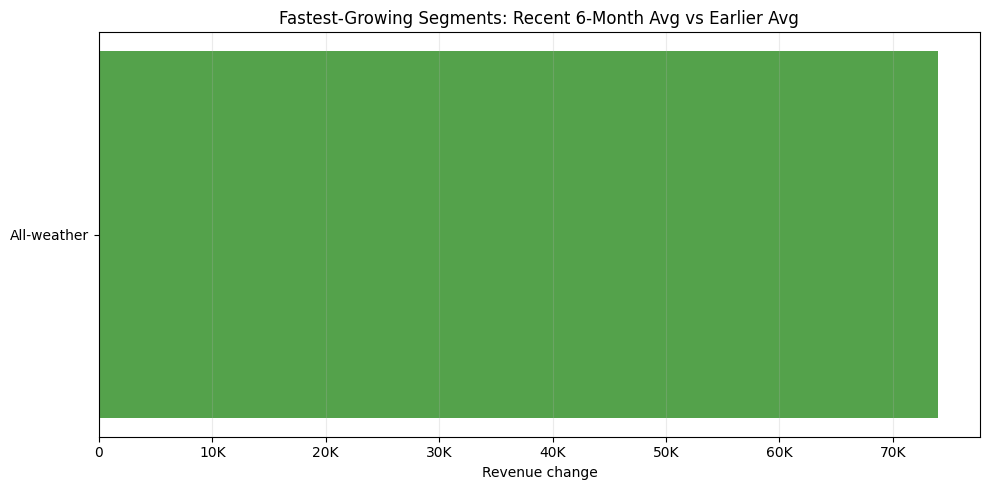

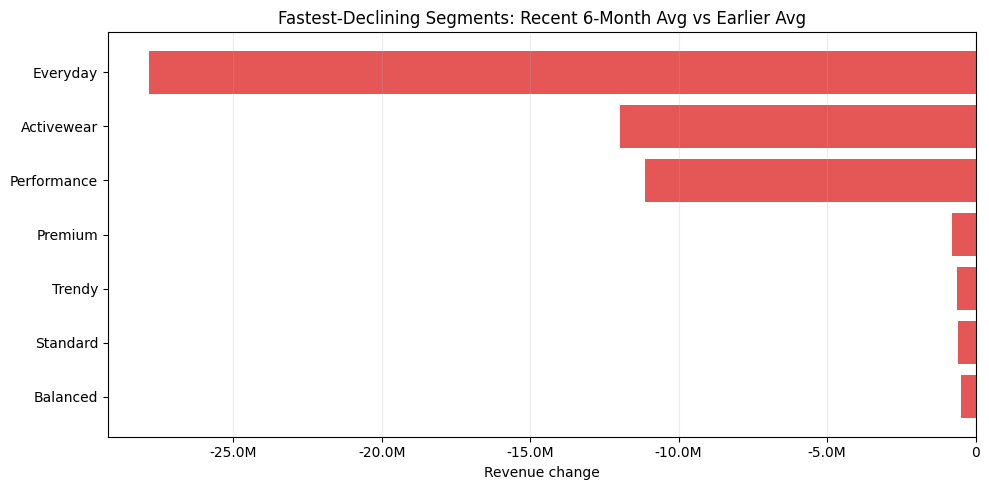

In [9]:
if not analysis_ready or monthly_pivot.empty:
    print("WARNING: Skipping segment growth analysis because monthly segment revenue is not available.")
else:
    total_revenue_all = segment_items["revenue"].sum()
    min_total_revenue = max(total_revenue_all * 0.005, 1)
    rows = []
    for segment in monthly_pivot.columns:
        series = monthly_pivot[segment].astype(float)
        positive = series[series > 0]
        total_seg_revenue = series.sum()
        observed_months = int((series > 0).sum())
        if positive.empty:
            continue
        first_month = positive.index[0]
        last_month = series.index[-1]
        first_revenue = float(series.loc[first_month])
        last_revenue = float(series.loc[last_month])
        absolute_change = last_revenue - first_revenue
        safe_start = first_revenue >= max(series[series > 0].median() * 0.10, 1)
        percentage_change = absolute_change / first_revenue * 100 if safe_start and first_revenue != 0 else np.nan
        recent_6_avg = float(series.tail(6).mean()) if len(series) >= 1 else np.nan
        earlier_window = series.iloc[:-6] if len(series) > 6 else series.iloc[:0]
        earlier_avg = float(earlier_window.mean()) if len(earlier_window) else np.nan
        recent_vs_earlier_abs = recent_6_avg - earlier_avg if pd.notna(earlier_avg) else np.nan
        recent_vs_earlier_pct = recent_vs_earlier_abs / earlier_avg * 100 if pd.notna(earlier_avg) and abs(earlier_avg) > 1e-9 else np.nan
        months_between = max(1, (last_month.year - first_month.year) * 12 + (last_month.month - first_month.month))
        cmgr = (last_revenue / first_revenue) ** (1 / months_between) - 1 if first_revenue > 0 and last_revenue > 0 else np.nan
        volatility = float(series.std(ddof=1)) if len(series) > 1 else np.nan
        coefficient_of_variation = volatility / abs(series.mean()) if series.mean() != 0 else np.nan
        rolling_6 = series.rolling(6, min_periods=3).mean()
        steady_growth_score = float((rolling_6.diff() > 0).mean()) if rolling_6.notna().sum() > 3 else np.nan
        meaningful = bool(total_seg_revenue >= min_total_revenue and observed_months >= 6)
        rows.append({
            "segment": segment,
            "total_revenue": total_seg_revenue,
            "observed_months": observed_months,
            "first_available_month": first_month,
            "first_available_month_revenue": first_revenue,
            "last_timeline_month": last_month,
            "last_timeline_month_revenue": last_revenue,
            "absolute_change_first_to_last": absolute_change,
            "percentage_change_first_to_last": percentage_change,
            "recent_6_month_avg": recent_6_avg,
            "earlier_avg_before_recent_6": earlier_avg,
            "recent_6_vs_earlier_abs": recent_vs_earlier_abs,
            "recent_6_vs_earlier_pct": recent_vs_earlier_pct,
            "compound_monthly_growth_rate": cmgr,
            "monthly_revenue_volatility": volatility,
            "monthly_coefficient_of_variation": coefficient_of_variation,
            "steady_growth_score": steady_growth_score,
            "meets_meaningful_threshold": meaningful,
        })
    growth_df = pd.DataFrame(rows).sort_values("recent_6_vs_earlier_abs", ascending=False)
    meaningful_growth = growth_df.loc[growth_df["meets_meaningful_threshold"]].copy()
    fastest_growing_df = meaningful_growth.loc[meaningful_growth["recent_6_vs_earlier_abs"] > 0].sort_values(["recent_6_vs_earlier_abs", "recent_6_vs_earlier_pct"], ascending=False).head(10)
    fastest_declining_df = meaningful_growth.loc[meaningful_growth["recent_6_vs_earlier_abs"] < 0].sort_values(["recent_6_vs_earlier_abs", "recent_6_vs_earlier_pct"], ascending=True).head(10)
    steady_growth_df = meaningful_growth.loc[(meaningful_growth["recent_6_vs_earlier_abs"] > 0) & (meaningful_growth["steady_growth_score"] >= 0.55)].sort_values(["steady_growth_score", "recent_6_vs_earlier_abs"], ascending=False).head(10)
    unstable_segment_df = meaningful_growth.sort_values("monthly_coefficient_of_variation", ascending=False).head(10)

    print("Segment growth indicators")
    display(growth_df)
    print("Steady growth candidates")
    display(steady_growth_df)
    print("Fastest-growing segments")
    display(fastest_growing_df)
    print("Fastest-declining segments")
    display(fastest_declining_df)
    print("Highest-volatility segments")
    display(unstable_segment_df)

    if not fastest_growing_df.empty:
        plot_df = fastest_growing_df.sort_values("recent_6_vs_earlier_abs")
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(plot_df["segment"].astype(str), plot_df["recent_6_vs_earlier_abs"], color="#54A24B")
        ax.set_title("Fastest-Growing Segments: Recent 6-Month Avg vs Earlier Avg")
        ax.set_xlabel("Revenue change")
        ax.xaxis.set_major_formatter(currency_axis)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

    if not fastest_declining_df.empty:
        plot_df = fastest_declining_df.sort_values("recent_6_vs_earlier_abs", ascending=False)
        fig, ax = plt.subplots(figsize=(10, 5))
        ax.barh(plot_df["segment"].astype(str), plot_df["recent_6_vs_earlier_abs"], color="#E45756")
        ax.set_title("Fastest-Declining Segments: Recent 6-Month Avg vs Earlier Avg")
        ax.set_xlabel("Revenue change")
        ax.xaxis.set_major_formatter(currency_axis)
        ax.grid(axis="x", alpha=0.25)
        plt.tight_layout()
        plt.show()

## 10. Segment share over time

Calculate monthly revenue share by segment and visualize segment mix. Small segments are grouped as `Other` if needed for readability.

,average_top1_monthly_share,latest_top1_monthly_share,top1_share_change_first_to_last_month,average_monthly_segment_hhi,latest_monthly_segment_hhi,avg_abs_monthly_share_change_top_segments,mix_change_statement
0,0.386624,0.456395,0.030462,0.26163,0.269926,0.015695,Segment mix changes over time: average absolute monthly share movement among top segments is 1.57%.


Segment mix changes over time: average absolute monthly share movement among top segments is 1.57%.


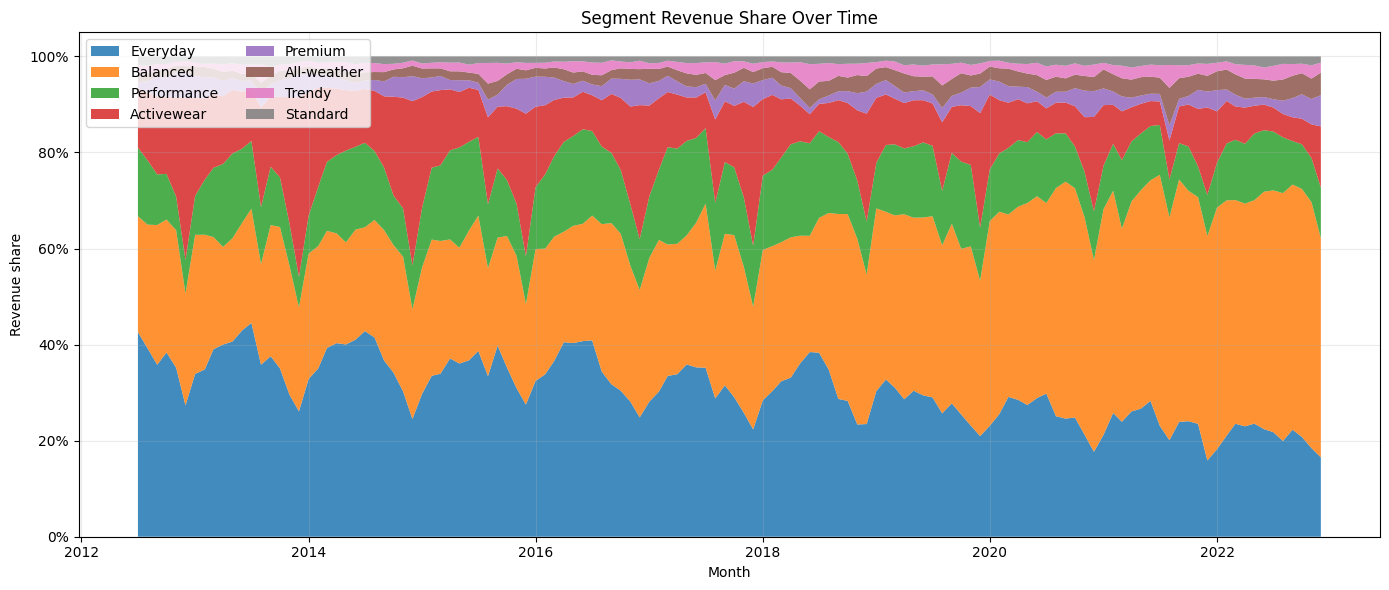

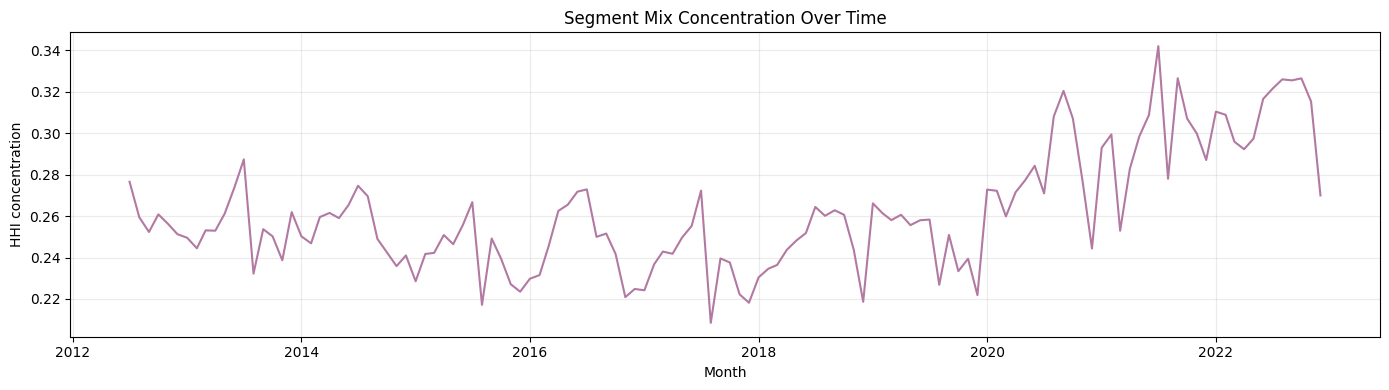

In [10]:
if not analysis_ready or monthly_pivot.empty:
    print("WARNING: Skipping segment share over time because monthly segment revenue is not available.")
else:
    top_share_segments = segment_revenue.head(min(TOP_N_SEGMENTS, len(segment_revenue)))["segment"].tolist()
    total_monthly_revenue = monthly_pivot.sum(axis=1)
    monthly_share = monthly_pivot.div(total_monthly_revenue.replace(0, np.nan), axis=0).fillna(0)
    monthly_share_plot_df = monthly_share[top_share_segments].copy()
    other_segments = [col for col in monthly_share.columns if col not in top_share_segments]
    if other_segments:
        monthly_share_plot_df["Other"] = monthly_share[other_segments].sum(axis=1)

    top1_share_by_month = monthly_share.max(axis=1)
    hhi_by_month = (monthly_share ** 2).sum(axis=1)
    avg_abs_share_change = monthly_share[top_share_segments].diff().abs().mean().mean()
    top1_change = top1_share_by_month.iloc[-1] - top1_share_by_month.iloc[0] if len(top1_share_by_month) > 1 else np.nan
    if pd.notna(avg_abs_share_change) and avg_abs_share_change >= 0.015:
        mix_change_statement = f"Segment mix changes over time: average absolute monthly share movement among top segments is {avg_abs_share_change:.2%}."
    else:
        mix_change_statement = f"Segment mix appears relatively stable: average absolute monthly share movement among top segments is {avg_abs_share_change:.2%}."

    mix_summary_df = pd.DataFrame([{
        "average_top1_monthly_share": top1_share_by_month.mean(),
        "latest_top1_monthly_share": top1_share_by_month.iloc[-1],
        "top1_share_change_first_to_last_month": top1_change,
        "average_monthly_segment_hhi": hhi_by_month.mean(),
        "latest_monthly_segment_hhi": hhi_by_month.iloc[-1],
        "avg_abs_monthly_share_change_top_segments": avg_abs_share_change,
        "mix_change_statement": mix_change_statement,
    }])
    display(mix_summary_df)
    print(mix_change_statement)

    fig, ax = plt.subplots(figsize=(14, 6))
    labels = [str(col) for col in monthly_share_plot_df.columns]
    ax.stackplot(monthly_share_plot_df.index, [monthly_share_plot_df[col] for col in monthly_share_plot_df.columns], labels=labels, alpha=0.85)
    ax.set_title("Segment Revenue Share Over Time")
    ax.set_xlabel("Month")
    ax.set_ylabel("Revenue share")
    ax.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax.grid(alpha=0.25)
    ax.legend(loc="upper left", ncol=2)
    plt.tight_layout()
    plt.show()

    fig, ax = plt.subplots(figsize=(14, 4))
    ax.plot(hhi_by_month.index, hhi_by_month, color="#B279A2", linewidth=1.5)
    ax.set_title("Segment Mix Concentration Over Time")
    ax.set_xlabel("Month")
    ax.set_ylabel("HHI concentration")
    ax.grid(alpha=0.25)
    plt.tight_layout()
    plt.show()

## 11. Leakage-safe segment forecast feature preview

Create example segment features using only historical segment revenue. Segment revenue is shifted before rolling shares, growth rates, and concentration are calculated.

In [11]:
if not analysis_ready:
    print("WARNING: Skipping forecast feature preview because the joined dataset is not available.")
else:
    daily_segment = (
        segment_items.groupby(["order_date", "segment"], as_index=False)
        .agg(revenue=("revenue", "sum"))
    )
    daily_pivot = daily_segment.pivot(index="order_date", columns="segment", values="revenue").fillna(0)
    full_days = pd.date_range(daily_pivot.index.min(), daily_pivot.index.max(), freq="D")
    daily_pivot = daily_pivot.reindex(full_days).fillna(0)
    daily_pivot.index.name = "date"
    daily_total = daily_pivot.sum(axis=1)

    global_top_segment = segment_revenue.iloc[0]["segment"] if not segment_revenue.empty else daily_pivot.columns[0]
    premium_segments = [col for col in daily_pivot.columns if is_premium_label(str(col))]
    shifted_segment = daily_pivot.shift(1)
    shifted_total = daily_total.shift(1)
    rolling_segment_30 = shifted_segment.rolling(window=30, min_periods=7).sum()
    rolling_total_30 = rolling_segment_30.sum(axis=1)
    rolling_shares_30 = rolling_segment_30.div(rolling_total_30.replace(0, np.nan), axis=0)
    segment_growth_rate_lag = rolling_segment_30[global_top_segment].pct_change().shift(1) if global_top_segment in rolling_segment_30.columns else pd.Series(np.nan, index=rolling_segment_30.index)

    premium_share_lag = rolling_shares_30[premium_segments].sum(axis=1) if premium_segments else pd.Series(np.nan, index=rolling_shares_30.index)

    feature_df = pd.DataFrame({
        "date": daily_pivot.index,
        "total_revenue": daily_total.values,
        "segment_revenue_lag": shifted_segment[global_top_segment].values if global_top_segment in shifted_segment.columns else np.nan,
        "segment_share_lag": rolling_shares_30[global_top_segment].values if global_top_segment in rolling_shares_30.columns else np.nan,
        "segment_growth_rate_lag": segment_growth_rate_lag.values,
        "top_segment_revenue_lag": shifted_segment[global_top_segment].values if global_top_segment in shifted_segment.columns else np.nan,
        "top_segment_share_lag": rolling_shares_30.max(axis=1).values,
        "segment_mix_concentration_lag": (rolling_shares_30.fillna(0) ** 2).sum(axis=1).values,
        "premium_segment_share_lag": premium_share_lag.values,
    })

    feature_preview = feature_df.dropna(subset=["segment_share_lag"]).head(20)
    if feature_preview.empty:
        feature_preview = feature_df.head(20)
    display(feature_preview)
    print("Leakage-safe construction: daily segment revenue is shifted by one day before lagged shares, growth, and concentration are calculated.")
    print(forecast_feature_warning)
    print("Recommended segment-level forecast features:", ", ".join(recommended_segment_features))

,date,total_revenue,segment_revenue_lag,segment_share_lag,segment_growth_rate_lag,top_segment_revenue_lag,top_segment_share_lag,segment_mix_concentration_lag,premium_segment_share_lag
7,2012-07-11,5582884.78,2487814.75,0.482378,NaN,2487814.75,0.482378,0.333421,0.005346
8,2012-07-12,5734632.02,3014731.43,0.492986,NaN,3014731.43,0.492986,0.333129,0.006951
9,2012-07-13,5309511.71,2498169.67,0.483864,0.252601,2498169.67,0.483864,0.321980,0.007260
10,2012-07-14,3820831.41,2296031.47,0.477264,0.167108,2296031.47,0.477264,0.316825,0.007590
11,2012-07-15,3948841.28,1727833.36,0.475146,0.131596,1727833.36,0.475146,0.314908,0.007424
12,2012-07-16,3503801.49,1649543.36,0.470531,0.087513,1649543.36,0.470531,0.313422,0.007037
13,2012-07-17,4476729.49,1338251.30,0.464635,0.076825,1338251.30,0.464635,0.308810,0.007278
14,2012-07-18,5184141.46,1721162.25,0.458352,0.057880,1721162.25,0.458352,0.304075,0.008148
15,2012-07-19,6421487.11,2281940.32,0.456840,0.070368,2281940.32,0.456840,0.300820,0.007658
16,2012-07-20,5171470.46,2609619.29,0.452126,0.087162,2609619.29,0.452126,0.297306,0.008274


Leakage-safe construction: daily segment revenue is shifted by one day before lagged shares, growth, and concentration are calculated.
Future segment mix must not be used directly for forecasting unless it is separately forecasted.
Recommended segment-level forecast features: segment_revenue_lag, segment_share_lag, segment_growth_rate_lag, top_segment_revenue_lag, top_segment_share_lag, segment_mix_concentration_lag, premium_segment_share_lag


## 12. Key observations and warnings

Summarize segment revenue leaders, weak segments, growth/decline, margin behavior, mix change, attention areas, and leakage-safe feature recommendations.

In [12]:
if analysis_ready and not segment_revenue.empty:
    top_segments_text = ", ".join(
        f"{row.segment} ({row.revenue_share:.1%})"
        for row in segment_revenue.head(5).itertuples()
    )
    weak_segments_text = ", ".join(
        f"{row.segment} ({row.revenue_share:.1%})"
        for row in segment_revenue.tail(5).itertuples()
    )
    if not steady_growth_df.empty:
        steady_text = ", ".join(
            f"{row.segment} (+{row.recent_6_vs_earlier_abs:,.0f}, steady score {row.steady_growth_score:.2f})"
            for row in steady_growth_df.head(3).itertuples()
        )
    elif not fastest_growing_df.empty:
        steady_text = ", ".join(
            f"{row.segment} ({row.recent_6_vs_earlier_abs:+,.0f})"
            for row in fastest_growing_df.head(3).itertuples()
        )
    else:
        steady_text = "None identified with thresholds"
    if not fastest_declining_df.empty:
        decline_text = ", ".join(
            f"{row.segment} ({row.recent_6_vs_earlier_abs:,.0f})"
            for row in fastest_declining_df.head(3).itertuples()
        )
    else:
        decline_text = "None identified with thresholds"
    unstable_text = ", ".join(unstable_segment_df.head(3)["segment"].astype(str).tolist()) if not unstable_segment_df.empty else "None identified"

    core_segments = segment_revenue.head(3)["segment"].astype(str).tolist()
    attention_text = f"Core revenue/inventory attention: {', '.join(core_segments)}; volatility monitoring: {unstable_text}"

    print("Insight summary")
    print(f"- Top revenue segments: {top_segments_text}")
    print(f"- Weakest revenue segments: {weak_segments_text}")
    print(f"- Segments with steady or fast growth: {steady_text}")
    print(f"- Segments with decline or instability: decline: {decline_text}; high volatility: {unstable_text}")
    print(f"- Premium/high-end margin behavior: {premium_margin_statement}")
    print(f"- Segment mix over time: {mix_change_statement}")
    print(f"- Segment groups that may deserve inventory or marketing attention: {attention_text}")
    print(f"- Recommended leakage-safe segment-level forecast features: {', '.join(recommended_segment_features)}")
    print(f"- Forecasting warning: {forecast_feature_warning}")
else:
    print("Insight summary")
    print("- Segment revenue analysis could not be completed because required joined data was not available.")

print("\nWarnings and data notes")
if warning_messages:
    for message in dict.fromkeys(warning_messages):
        print(f"- {message}")
else:
    print("- No critical warnings.")

Insight summary
- Top revenue segments: Everyday (32.7%), Balanced (31.2%), Performance (14.5%), Activewear (12.5%), Premium (2.9%)
- Weakest revenue segments: Activewear (12.5%), Premium (2.9%), All-weather (2.6%), Trendy (2.1%), Standard (1.4%)
- Segments with steady or fast growth: All-weather (+73,982)
- Segments with decline or instability: decline: Everyday (-27,831,946), Activewear (-11,983,021), Performance (-11,128,713); high volatility: Trendy, Performance, Everyday
- Premium/high-end margin behavior: Premium/high-end labeled segments appear weaker on average margin: 10.94% vs 14.75% for other segments.
- Segment mix over time: Segment mix changes over time: average absolute monthly share movement among top segments is 1.57%.
- Segment groups that may deserve inventory or marketing attention: Core revenue/inventory attention: Everyday, Balanced, Performance; volatility monitoring: Trendy, Performance, Everyday
- Recommended leakage-safe segment-level forecast features: segmen